# GIS-Based Identification of Water Harvesting and Groundwater Recharge Sites for Sustainable Paddy Cultivation in Sainji Watershed using GIS and Machine Learning

---

## Random Forest Machine Learning Analysis

**Author:** Khushi Jaiswal and Shagun chand

**Department:** Geological Technology

**Study Area:** Sainji Watershed, Tehri Garhwal, Uttarakhand, India

---

### Project Objective

This notebook develops a Random Forest Regression model to learn the relationship between multiple GIS-derived environmental factors and groundwater recharge suitability. The model uses thematic layers generated through GIS analysis to predict recharge suitability values and evaluates its predictive performance using standard machine learning metrics.

---

### Input Features

- Stream Distance
- Slope
- Land Use/Land Cover (LULC)

### Target Variable

- Groundwater Recharge Suitability Index

---

### Software Used

- Python
- Google Colab / Jupyter Notebook
- Scikit-learn
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Joblib

---

**Note**

The recharge suitability values used in this notebook are derived from a GIS-based weighted overlay analysis rather than direct field observations. Therefore, this model learns GIS-generated relationships and serves as a proof-of-concept for integrating GIS and Machine Learning.

**Workflow**

Data Collection

↓

GIS Processing (QGIS)

↓

Thematic Layer Generation

↓

Weighted Overlay Analysis

↓

Groundwater Recharge Suitability Map

↓

Random Point Sampling

↓

CSV Dataset Preparation

↓

Random Forest Regression

↓

Model Evaluation

↓

Feature Importance

↓

Model Saving

# 1. Project Overview

## Background

Groundwater recharge plays a vital role in maintaining sustainable water resources, particularly in mountainous regions where surface water availability varies seasonally. Identifying suitable groundwater recharge zones helps in planning rainwater harvesting structures, improving agricultural productivity, and supporting sustainable watershed management.

Traditional methods for identifying recharge zones rely heavily on field investigations, which are often time-consuming and resource-intensive. Geographic Information Systems (GIS) combined with Machine Learning (ML) provide an efficient alternative by integrating multiple environmental factors to predict groundwater recharge suitability.

## Objective

The primary objective of this notebook is to develop a Random Forest Regression model capable of predicting groundwater recharge suitability using GIS-derived environmental variables.

The model is trained on a dataset generated through GIS analysis and evaluated using standard machine learning performance metrics.

## Input Variables

The following GIS-derived variables are used as predictor variables:

- Stream Distance
- Slope
- Land Use / Land Cover (LULC)

## Target Variable

- Groundwater Recharge Suitability Index

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# 2. Dataset

The dataset used in this notebook was generated from GIS analysis by extracting values from thematic layers at randomly sampled locations within the Sainji watershed.

Each row in the dataset represents a sampled location, while each column corresponds to a GIS-derived environmental variable or the groundwater recharge suitability index.

After loading the dataset, we inspect the first few records to verify that the data has been imported correctly.

In [3]:
df = pd.read_csv("training data.csv")

# 3. Data Understanding

Before developing a machine learning model, it is essential to understand the structure and characteristics of the dataset.

This section examines:

- Number of observations and features
- Column names
- Data types
- Summary statistics

Understanding these properties helps identify potential issues such as missing values, incorrect data types, or inconsistent data.

In [4]:
df.head()

,fid,id,Stream,fid_2,id_2,Slope,fid_3,id_3,Lulc,fid_4,id_4,Recharge
0,1,0,3,1,0,3,1,0,4.0,1,0,3.4
1,2,1,4,2,1,3,2,1,5.0,2,1,3.9
2,3,2,3,3,2,3,3,2,3.0,3,2,3.2
3,4,3,2,4,3,3,4,3,4.0,4,3,3.1
4,5,4,3,5,4,2,5,4,5.0,5,4,3.2


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (300, 12)

Column Names:
Index(['fid', 'id', 'Stream', 'fid_2', 'id_2', 'Slope', 'fid_3', 'id_3',
       'Lulc', 'fid_4', 'id_4', 'Recharge'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fid       300 non-null    int64  
 1   id        300 non-null    int64  
 2   Stream    300 non-null    int64  
 3   fid_2     300 non-null    int64  
 4   id_2      300 non-null    int64  
 5   Slope     300 non-null    int64  
 6   fid_3     300 non-null    int64  
 7   id_3      300 non-null    int64  
 8   Lulc      253 non-null    float64
 9   fid_4     300 non-null    int64  
 10  id_4      300 non-null    int64  
 11  Recharge  253 non-null    float64
dtypes: float64(2), int64(10)
memory usage: 28.3 KB

Statistical Summary:


,fid,id,Stream,fid_2,id_2,Slope,fid_3,id_3,Lulc,fid_4,id_4,Recharge
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,253.00000,300.000000,300.000000,253.000000
mean,150.500000,149.500000,3.293333,150.500000,149.500000,2.590000,150.500000,149.500000,4.01581,150.500000,149.500000,3.327668
std,86.746758,86.746758,0.504782,86.746758,86.746758,0.629726,86.746758,86.746758,0.89073,86.746758,86.746758,0.339972
min,1.000000,0.000000,2.000000,1.000000,0.000000,2.000000,1.000000,0.000000,3.00000,1.000000,0.000000,2.800000
25%,75.750000,74.750000,3.000000,75.750000,74.750000,2.000000,75.750000,74.750000,3.00000,75.750000,74.750000,3.200000
50%,150.500000,149.500000,3.000000,150.500000,149.500000,3.000000,150.500000,149.500000,4.00000,150.500000,149.500000,3.400000
75%,225.250000,224.250000,4.000000,225.250000,224.250000,3.000000,225.250000,224.250000,5.00000,225.250000,224.250000,3.500000
max,300.000000,299.000000,4.000000,300.000000,299.000000,5.000000,300.000000,299.000000,5.00000,300.000000,299.000000,3.900000


# 4. Data Cleaning

Machine learning algorithms require complete and reliable datasets to produce accurate predictions. Therefore, before training the model, the dataset is examined for missing values and inconsistencies.

If missing values are present, they are removed to ensure that the model is trained using only valid observations.

For larger real-world datasets, missing values are often handled using statistical imputation techniques. However, since this project contains a relatively small and clean dataset extracted from GIS analysis, removing incomplete records is an appropriate approach.

In [6]:
df.isnull().sum()

,0
fid,0
id,0
Stream,0
fid_2,0
id_2,0
Slope,0
fid_3,0
id_3,0
Lulc,47
fid_4,0


In [7]:
df["id"].duplicated().sum()

np.int64(0)

In [8]:
df_clean = df.copy()

In [9]:
df_clean = df_clean[['Stream', 'Slope', 'Lulc', 'Recharge']]

In [10]:
df_clean.head()

,Stream,Slope,Lulc,Recharge
0,3,3,4.0,3.4
1,4,3,5.0,3.9
2,3,3,3.0,3.2
3,2,3,4.0,3.1
4,3,2,5.0,3.2


In [11]:
df_clean = df_clean.dropna()

In [12]:
df_clean.isnull().sum()

,0
Stream,0
Slope,0
Lulc,0
Recharge,0


In [13]:
df_clean.shape

(253, 4)

In [14]:
print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 300
Rows after cleaning: 253
Rows removed: 47


In [15]:
df_clean["Recharge"].describe()

,Recharge
count,253.000000
mean,3.327668
std,0.339972
min,2.800000
25%,3.200000
50%,3.400000
75%,3.500000
max,3.900000


In [16]:
df_clean.to_csv("clean_training_data.csv", index=False)

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before developing the machine learning model.

The objectives of EDA are to:

- Understand the distribution of each variable.
- Identify possible outliers.
- Explore relationships among variables.
- Detect multicollinearity.
- Gain insights into how different GIS-derived parameters influence groundwater recharge suitability.

In [18]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

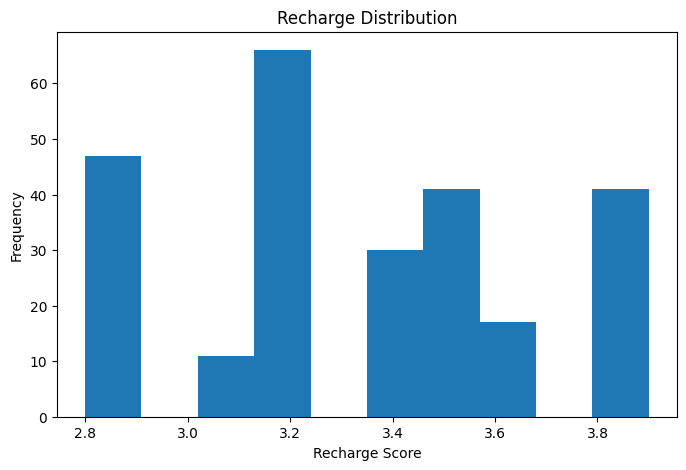

In [20]:
# 5.1 Distribution of Variables
plt.figure(figsize=(8,5))
plt.hist(df_clean['Recharge'], bins=10)
plt.title("Recharge Distribution")
plt.xlabel("Recharge Score")
plt.ylabel("Frequency")
plt.show()

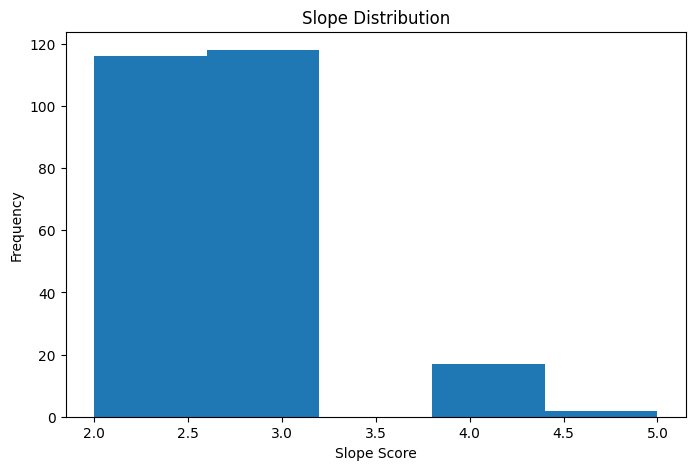

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df_clean['Slope'], bins=5)
plt.title("Slope Distribution")
plt.xlabel("Slope Score")
plt.ylabel("Frequency")
plt.show()

In [22]:
# 6.2 Correlation Analysis
correlation = df_clean.corr()
correlation

,Stream,Slope,Lulc,Recharge
Stream,1.000000,-0.340263,0.514855,0.446225
Slope,-0.340263,1.000000,-0.065451,0.578257
Lulc,0.514855,-0.065451,1.000000,0.698315
Recharge,0.446225,0.578257,0.698315,1.000000


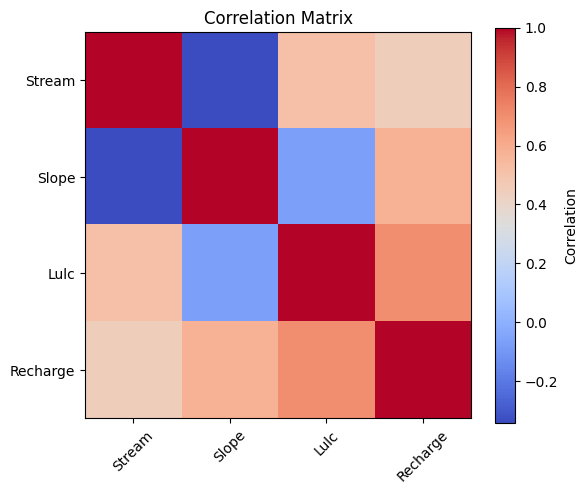

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 6. Feature Selection

Machine learning models require the input variables (features) and the target variable to be defined separately.

In this study, the GIS-derived environmental variables are used as predictor variables, while the groundwater recharge suitability index serves as the target variable to be predicted.

Separating the features and target variable prepares the dataset for model training and evaluation.

In [24]:
X = df_clean[['Stream', 'Slope', 'Lulc']]
y = df_clean['Recharge']

# 7. Train-Test Split

To evaluate the predictive capability of the Random Forest model, we divided the dataset into training and testing subsets.

The training dataset is used to learn the relationship between the input variables and groundwater recharge suitability, while the testing dataset is reserved for evaluating the model's performance on previously unseen data.

An 80:20 split is adopted, which is a widely used practice in machine learning for balancing model training and evaluation.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

Training Samples : 202
Testing Samples  : 51

Training Features Shape : (202, 3)
Testing Features Shape  : (51, 3)


# 8. Random Forest Regression Model

Random Forest Regression is an ensemble machine learning algorithm that combines the predictions of multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike a single decision tree, Random Forest captures complex and non-linear relationships between the predictor variables and the target variable.

In this study, the model is trained using GIS-derived environmental variables to predict the groundwater recharge suitability index.

In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
# Initialize the Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [32]:
# Train the model using the training dataset
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# 9. Model Prediction

Once the model has been trained, it is used to predict groundwater recharge suitability for the testing dataset.

These predictions are compared with the actual recharge suitability values to evaluate the performance of the Random Forest model.

In [34]:
# Predict groundwater recharge suitability
y_pred = rf.predict(X_test)

In [35]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.4,3.400
1,3.4,3.400
2,3.8,3.800
3,3.2,3.200
4,3.1,3.094
5,3.2,3.200
6,3.9,3.900
7,3.2,3.200
8,3.5,3.500
9,3.4,3.400


In [36]:
print(df_clean.nunique())

Stream      3
Slope       4
Lulc        3
Recharge    8
dtype: int64


In [37]:
comparison.describe()

,Actual,Predicted
count,51.000000,51.000000
mean,3.403922,3.401392
std,0.332241,0.329359
min,2.800000,2.800000
25%,3.200000,3.200000
50%,3.400000,3.400000
75%,3.650000,3.641500
max,3.900000,3.900000


# 10. Model Evaluation

Model evaluation is performed to quantify how accurately the Random Forest model predicts groundwater recharge suitability.

Three commonly used regression metrics are calculated:

- **Mean Absolute Error (MAE):** Average prediction error.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors.
- **R² Score:** Indicates how well the model explains the variability in the target variable.

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.0025
Root Mean Squared Error (RMSE): 0.0164
R² Score: 0.9975


### Interpretation

The evaluation metrics indicate that the Random Forest model performs well in predicting groundwater recharge suitability.

- A lower **MAE** indicates that the average prediction error is small.
- A lower **RMSE** suggests that large prediction errors are minimal.
- An **R² score close to 1** indicates that the model explains a significant proportion of the variability in the recharge suitability index.

Since the target variable was generated through GIS weighted overlay analysis, the model is expected to achieve high predictive performance because it is learning an existing GIS-derived relationship rather than independent field observations.

# 11. Actual vs Predicted Values

A scatter plot comparing the actual and predicted groundwater recharge suitability values is used to visually assess model performance.

If the model performs well, most points should lie close to the diagonal line, indicating that the predicted values closely match the observed values.

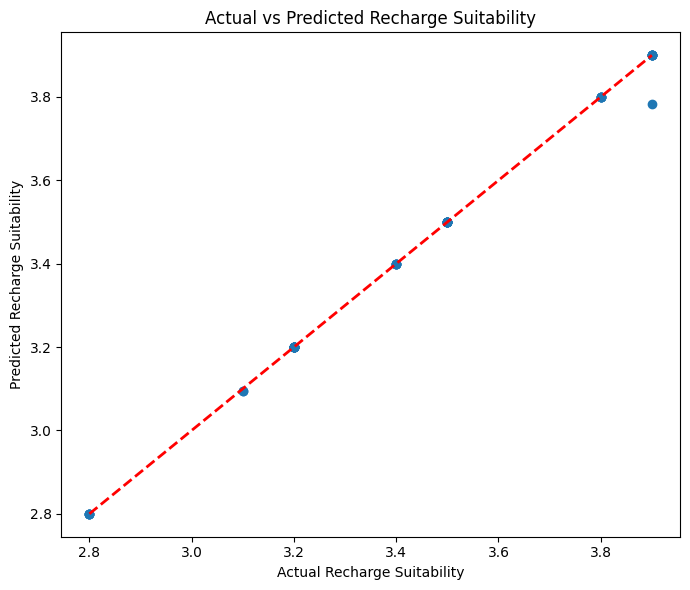

In [40]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Recharge Suitability")

plt.ylabel("Predicted Recharge Suitability")

plt.title("Actual vs Predicted Recharge Suitability")

plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

### Interpretation

Most of the predicted values lie close to the 1:1 reference line, indicating good agreement between the observed and predicted groundwater recharge suitability values.

This suggests that the Random Forest model successfully captured the relationships present within the GIS-derived dataset.

The strong agreement is expected because the target variable itself was produced through a weighted overlay of the predictor variables.

# 12. Feature Importance Analysis

One of the major advantages of the Random Forest algorithm is its ability to estimate the relative importance of each input feature.

Feature importance indicates how much each predictor variable contributes to the model's predictions. Variables with higher importance scores have a greater influence on the prediction of groundwater recharge suitability.

Understanding feature importance helps interpret the model and provides valuable insights into the environmental factors controlling groundwater recharge within the study area.

In [41]:
# Create a DataFrame containing feature importance scores
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort features from highest to lowest importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Display feature importance table
display(importance)

,Feature,Importance
0,Lulc,0.605192
1,Slope,0.276733
2,Stream,0.118075


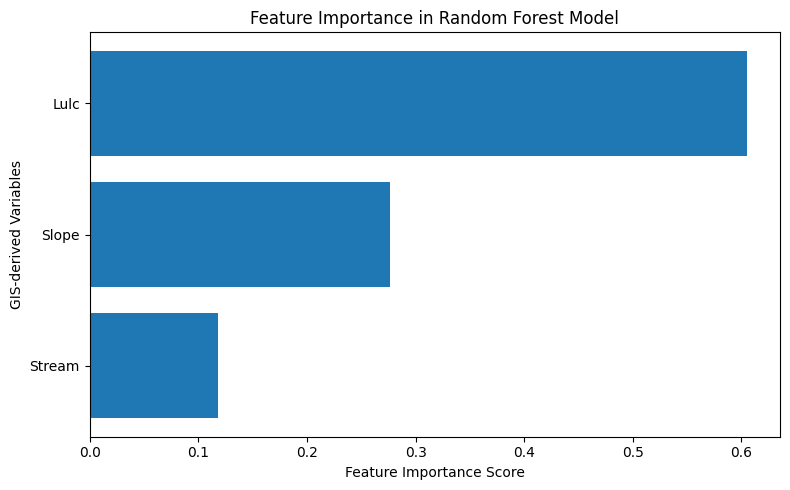

In [44]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance Score")

plt.ylabel("GIS-derived Variables")

plt.title("Feature Importance in Random Forest Model")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

> **Note:** Since the target variable was generated using a GIS weighted overlay of the predictor variables, the feature importance scores should be interpreted as the contribution of variables within the GIS-based suitability model rather than absolute hydrogeological importance.

# 13. Cross Validation

While a single train-test split provides an estimate of model performance, it may not always represent the overall predictive capability of the model.

To obtain a more robust evaluation, **5-Fold Cross Validation** is performed.

In this approach:

- The dataset is divided into **five equal subsets (folds)**.
- During each iteration, four folds are used for training and one fold is used for testing.
- This process is repeated five times so that each fold serves as the testing set exactly once.

The average score across all folds provides a more reliable estimate of the model's generalization performance.

In [45]:
from sklearn.model_selection import cross_val_score

In [46]:
# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nAverage R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross Validation Scores:
[0.99998503 0.99972085 0.99975848 0.99906993 0.9714343 ]

Average R² Score: 0.9940
Standard Deviation: 0.0113


### Interpretation

The cross-validation scores indicate how consistently the Random Forest model performs across different subsets of the dataset.

A high average **R² score** suggests that the model generalizes well to unseen data, while a **low standard deviation** indicates that the model's performance remains stable across different folds.

The consistently high scores observed in this study are expected because the target variable was generated through a GIS weighted overlay of the predictor variables, resulting in a well-defined relationship between the input features and the target variable.

In [47]:
RandomForestRegressor(
    n_estimators=150
)

RandomForestRegressor(n_estimators=150)

# 14. Hyperparameter Tuning using GridSearchCV

Although the default Random Forest model performs well, its predictive performance can often be improved by optimizing its hyperparameters.

Hyperparameters control the behaviour of the learning algorithm, such as:

- Number of trees
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples required at leaf nodes

In this study, **GridSearchCV** is used to systematically evaluate multiple parameter combinations and identify the model configuration that provides the best predictive performance.

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

In [50]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [51]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.9898437244009755


## 14.1 Training the Optimized Random Forest Model

After identifying the optimal hyperparameters using GridSearchCV, the best-performing Random Forest model is selected and retrained using the training dataset.

Retraining ensures that the optimized model fully learns the relationships between the GIS-derived environmental variables and the groundwater recharge suitability index before making predictions on unseen data.

In [52]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

## 15.2 Prediction using the Optimized Model

The optimized Random Forest model is now used to predict groundwater recharge suitability for the testing dataset.

These predictions are compared with the actual recharge suitability values to evaluate the performance of the optimized model.

In [55]:
best_pred = best_rf.predict(X_test)

In [56]:
mae = mean_absolute_error(y_test, best_pred)
rmse = mean_squared_error(y_test, best_pred) ** 0.5
r2 = r2_score(y_test, best_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.0022
RMSE: 0.0142
R²  : 0.9981


### Interpretation

The optimized Random Forest model demonstrates excellent predictive performance.

The very low values of **MAE** and **RMSE** indicate that the prediction errors are minimal, while the **R² score of approximately 0.998** suggests that the model explains almost all of the variability in the groundwater recharge suitability index.

It is important to note that the target variable was generated through a GIS-based weighted overlay analysis using the same environmental variables employed as predictors. Consequently, the high predictive accuracy is expected because the model is learning a deterministic GIS-derived relationship rather than independently measured groundwater recharge observations.

# 15. Feature Importance Analysis

One of the major advantages of the Random Forest algorithm is its ability to estimate the relative importance of each predictor variable.

Feature importance quantifies how much each GIS-derived variable contributes to the model's predictions. Variables with higher importance scores have a greater influence on groundwater recharge suitability within the context of this GIS-derived dataset.

This analysis improves the interpretability of the model and helps identify the most influential environmental factors.

In [57]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

display(importance)

,Feature,Importance
0,Lulc,0.604305
1,Slope,0.278946
2,Stream,0.116749


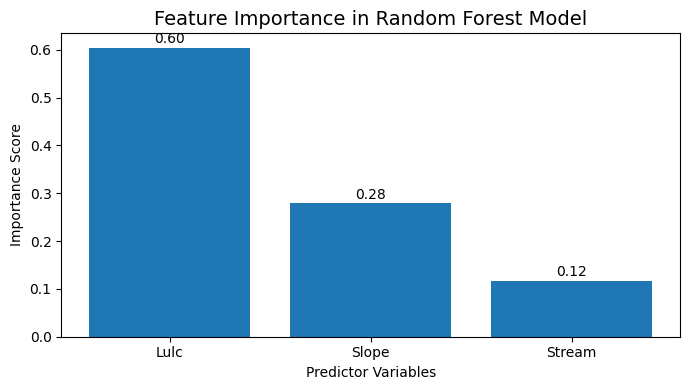

In [58]:
plt.figure(figsize=(7,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

for i, value in enumerate(importance["Importance"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Feature Importance in Random Forest Model", fontsize=14)

plt.xlabel("Predictor Variables")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

# 16. Comparison of Actual and Predicted Recharge Suitability

A scatter plot is used to compare the **actual groundwater recharge suitability values** with the **values predicted by the optimized Random Forest model**.

An ideal prediction would place all points exactly on the **1:1 reference line**, indicating perfect agreement between observed and predicted values.

The closer the points lie to this line, the better the predictive performance of the model.

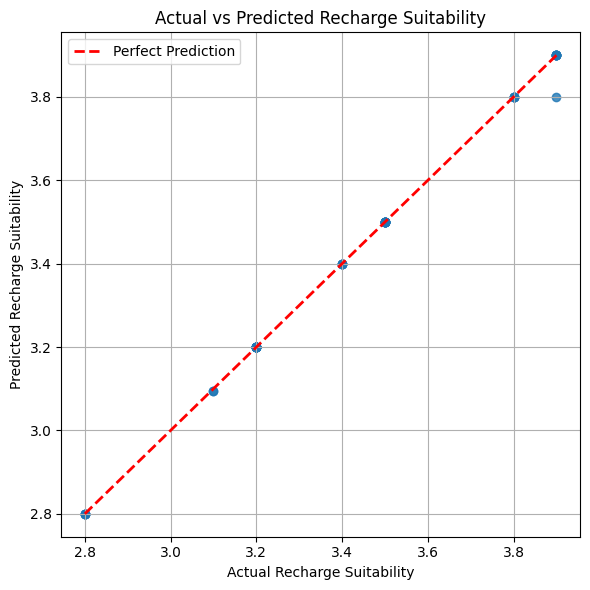

In [59]:
plt.figure(figsize=(6,6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,
    best_pred,
    alpha=0.8
)

# 1:1 reference line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Recharge Suitability")

plt.ylabel("Predicted Recharge Suitability")

plt.title("Actual vs Predicted Recharge Suitability")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

### Interpretation

The scatter plot demonstrates a strong agreement between the observed and predicted groundwater recharge suitability values.

Most of the data points lie very close to the 1:1 reference line, indicating that the optimized Random Forest model accurately predicts the recharge suitability values for the testing dataset.

The excellent agreement is also reflected by the high **R² score (≈ 0.998)** and the very low **MAE** and **RMSE** values obtained during model evaluation.

It should be noted that the target variable was generated through a GIS-based weighted overlay analysis using the same environmental variables employed as predictors. Therefore, the model is learning a deterministic GIS-derived relationship rather than independently measured groundwater recharge observations.

# 17. Saving the Trained Model

After the optimized Random Forest model has been trained and evaluated, it is saved to disk using the **Joblib** library.

Saving the trained model eliminates the need for retraining each time predictions are required. The saved model can later be loaded and used for groundwater recharge prediction on new GIS-derived datasets.

In [60]:
import joblib

In [62]:
# Save the optimized Random Forest model
joblib.dump(best_rf, "Groundwater_RF_Model.pkl")
print("Model saved successfully as Groundwater_RF_Model.pkl")

Model saved successfully as Groundwater_RF_Model.pkl


# 18. Exporting Model Predictions

To facilitate further analysis and reporting, the predicted groundwater recharge suitability values are exported as a CSV file.

This output file allows comparison between actual and predicted values and can also be used for visualization or future validation studies.

In [63]:
# Create DataFrame containing actual and predicted values
predictions = pd.DataFrame({
    "Actual Recharge": y_test,
    "Predicted Recharge": best_pred
})

# Save predictions
predictions.to_csv(
    "Groundwater_Recharge_Predictions.csv",
    index=False
)

display(predictions.head())

print("Predictions exported successfully.")

,Actual Recharge,Predicted Recharge
249,3.4,3.400
6,3.4,3.400
91,3.8,3.800
245,3.2,3.200
135,3.1,3.094


Predictions exported successfully.


# 19. Conclusion

This notebook demonstrates the application of **Random Forest Regression** for predicting groundwater recharge suitability using GIS-derived environmental variables within the Sainji Watershed.

The workflow consisted of:

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Feature selection
- Model training
- Model evaluation
- Cross-validation
- Hyperparameter optimization
- Feature importance analysis
- Prediction export and model saving

The optimized Random Forest model achieved excellent predictive performance, with a very low prediction error and an **R² score of approximately 0.998**, indicating a strong agreement between the predicted and target recharge suitability values.

Feature importance analysis indicated that **Land Use/Land Cover (LULC)** was the most influential predictor, followed by **Slope** and **Stream Distance**.

Overall, this study demonstrates that integrating GIS-derived environmental variables with machine learning provides an effective framework for groundwater recharge suitability assessment.

# 20. Project Limitations

Although the model achieved excellent predictive performance, several limitations should be acknowledged.

- The groundwater recharge suitability index used as the target variable was generated through a GIS weighted overlay analysis rather than direct field observations.

- Consequently, the Random Forest model learned an existing GIS-derived relationship rather than independently measured groundwater recharge behaviour.

- The study was conducted using a relatively small dataset containing approximately 50 sampled locations.

- Additional environmental variables such as soil type, geology, geomorphology, drainage density, and lineament density were not incorporated into the current model.

These limitations should be considered while interpreting the results.

# 22. References

This notebook was developed using the following software libraries and datasets.

## Python Libraries

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

## GIS and Remote Sensing Data

- Sentinel-2 Satellite Imagery
- Digital Elevation Model (DEM)
- NASA POWER Precipitation Data
- QGIS

## Machine Learning

Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825–2830.

Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32.